# 03 - Modeling Baselines

In this notebook, we compare several models on the processed modeling table. The aim is to choose a solid model before moving to score construction and calibration.

## 1. Setup

We reuse the modeling helpers from `credit_default.modeling` so the metrics and threshold logic stay consistent.

In [1]:
%matplotlib inline

In [2]:
from pathlib import Path
import sys
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from credit_default.config import MODELS_DIR, PROCESSED_DATA_DIR, TABLES_DIR  # noqa: E402
from credit_default.data import TARGET_COLUMN, load_credit_data  # noqa: E402
from credit_default.modeling import (  # noqa: E402
    RANDOM_STATE,
    binary_classification_metrics,
    build_pipeline,
    build_threshold_table,
    choose_threshold_by_f1,
    confusion_matrix_frame,
    evaluate_classifier,
    load_modeling_base,
    positive_class_scores,
    split_features_target,
)
from credit_default.preprocessing import (  # noqa: E402
    MODEL_CATEGORICAL_COLUMNS,
    MODEL_NUMERIC_COLUMNS,
    build_modeling_base,
)

try:
    from xgboost import XGBClassifier
except ImportError:  # pragma: no cover - notebook fallback
    XGBClassifier = None

try:
    from lightgbm import LGBMClassifier
except ImportError:  # pragma: no cover - notebook fallback
    LGBMClassifier = None

try:
    from catboost import CatBoostClassifier
except ImportError:  # pragma: no cover - notebook fallback
    CatBoostClassifier = None

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

TABLES_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

PROJECT_ROOT

WindowsPath('C:/Users/chris/OneDrive/Dokumente/projet/credit client')

## 2. Load Modeling Base

The notebook uses `data/processed/credit_default_modeling_base.csv`. If the file is missing, it is rebuilt from the raw data using the project preprocessing logic.

In [3]:
modeling_path = PROCESSED_DATA_DIR / "credit_default_modeling_base.csv"

if modeling_path.exists():
    modeling = load_modeling_base(modeling_path)
else:
    raw = load_credit_data()
    modeling = build_modeling_base(raw)
    modeling.to_csv(modeling_path, index=False)

print(f"Modeling shape: {modeling.shape[0]:,} rows x {modeling.shape[1]} columns")
print(f"Target default rate: {modeling[TARGET_COLUMN].mean():.2%}")
display(modeling.head())

Modeling shape: 30,000 rows x 63 columns
Target default rate: 22.12%


,ID,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,bill_to_limit_1,bill_to_limit_2,bill_to_limit_3,bill_to_limit_4,bill_to_limit_5,bill_to_limit_6,payment_to_bill_1,payment_to_bill_2,payment_to_bill_3,payment_to_bill_4,payment_to_bill_5,payment_to_bill_6,payment_to_limit_1,payment_to_limit_2,payment_to_limit_3,payment_to_limit_4,payment_to_limit_5,payment_to_limit_6,delinquency_months,severe_delinquency_months,max_delay_status,recent_delay_status,mean_positive_delay,months_no_consumption,months_paid_duly,months_revolving_credit,negative_bill_months,non_positive_bill_months,bill_above_limit_months,zero_payment_months,max_utilization,mean_utilization,total_bill_amount,total_positive_bill_amount,total_payment_amount,total_payment_to_bill,mean_payment_to_bill,mean_payment_to_limit,sex_group,education_group,marriage_group,PAY_0_category,PAY_2_category,PAY_3_category,PAY_4_category,PAY_5_category,PAY_6_category,default_payment_next_month
0,1,20000,24,3913,3102,689,0,0,0,0,689,0,0,0,0,0.1956,0.1551,0.0345,0.0000,0.0000,0.0000,0.0000,0.2221,0.0000,0.0000,0.0000,0.0000,0.0000,0.0345,0.0000,0.0000,0.0000,0.0000,2,2,2,2,0.6667,2,2,0,0,3,0,5,0.1956,0.0642,7704,7704,689,0.0894,0.0370,0.0057,female,university,married,delay_2_months,delay_2_months,paid_duly,paid_duly,no_consumption,no_consumption,1
1,2,120000,26,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,0.0223,0.0144,0.0223,0.0273,0.0288,0.0272,0.0000,0.5797,0.3729,0.3056,0.0000,0.6133,0.0000,0.0083,0.0083,0.0083,0.0000,0.0167,2,2,2,-1,0.6667,0,1,3,0,0,0,2,0.0288,0.0237,17077,17077,5000,0.2928,0.3119,0.0069,female,university,single,paid_duly,delay_2_months,revolving_credit,revolving_credit,revolving_credit,delay_2_months,1
2,3,90000,34,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0.3249,0.1559,0.1507,0.1592,0.1661,0.1728,0.0519,0.1069,0.0738,0.0698,0.0669,0.3216,0.0169,0.0167,0.0111,0.0111,0.0111,0.0556,0,0,0,0,0.0000,0,0,6,0,0,0,0,0.3249,0.1882,101653,101653,11018,0.1084,0.1151,0.0204,female,university,single,revolving_credit,revolving_credit,revolving_credit,revolving_credit,revolving_credit,revolving_credit,0
3,4,50000,37,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0.9398,0.9647,0.9858,0.5663,0.5792,0.5909,0.0426,0.0419,0.0243,0.0389,0.0369,0.0338,0.0400,0.0404,0.0240,0.0220,0.0214,0.0200,0,0,0,0,0.0000,0,0,6,0,0,0,0,0.9858,0.7711,231334,231334,8388,0.0363,0.0364,0.0280,female,university,married,revolving_credit,revolving_credit,revolving_credit,revolving_credit,revolving_credit,revolving_credit,0
4,5,50000,57,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0.1723,0.1134,0.7167,0.4188,0.3829,0.3826,0.2321,6.4693,0.2791,0.4298,0.0360,0.0355,0.0400,0.7336,0.2000,0.1800,0.0138,0.0136,0,0,0,-1,0.0000,0,2,4,0,0,0,0,0.7167,0.3645,109339,109339,59049,0.5401,1.2470,0.1968,male,university,married,paid_duly,revolving_credit,paid_duly,revolving_credit,revolving_credit,revolving_credit,0


In [4]:
modeling_profile = pd.DataFrame(
    {
        "role": ["numeric", "categorical", "id", "target"],
        "n_columns": [len(MODEL_NUMERIC_COLUMNS), len(MODEL_CATEGORICAL_COLUMNS), 1, 1],
    }
)
display(modeling_profile)

assert modeling.isna().sum().sum() == 0
assert set(modeling[TARGET_COLUMN].unique()) == {0, 1}

,role,n_columns
0,numeric,52
1,categorical,9
2,id,1
3,target,1


## 3. Train / Validation / Test Split

The split is stratified to preserve the default rate. Validation is used for model and threshold selection; test is reserved for final evaluation.

In [5]:
X, y = split_features_target(modeling)

X_train_valid, X_test, y_train_valid, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=RANDOM_STATE,
)

valid_size_relative = 0.15 / 0.85
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_valid,
    y_train_valid,
    test_size=valid_size_relative,
    stratify=y_train_valid,
    random_state=RANDOM_STATE,
)

split_summary = pd.DataFrame(
    [
        {"split": "train", "rows": len(y_train), "default_rate": y_train.mean()},
        {"split": "validation", "rows": len(y_valid), "default_rate": y_valid.mean()},
        {"split": "test", "rows": len(y_test), "default_rate": y_test.mean()},
    ]
)
display(split_summary)

,split,rows,default_rate
0,train,21000,0.2212
1,validation,4500,0.2211
2,test,4500,0.2211


## 4. Candidate Models

We compare a naive baseline, logistic regression, class-weighted logistic regression, random forest, histogram gradient boosting, XGBoost, LightGBM, and CatBoost.

In [6]:
def positive_class_weight(y_values: pd.Series) -> float:
    negatives = (y_values == 0).sum()
    positives = (y_values == 1).sum()
    return negatives / positives


def make_catboost(auto_class_weights: str | None = None):
    if CatBoostClassifier is None:
        return None
    return CatBoostClassifier(
        iterations=500,
        learning_rate=0.035,
        depth=5,
        l2_leaf_reg=5.0,
        random_strength=1.0,
        loss_function="Logloss",
        eval_metric="PRAUC",
        auto_class_weights=auto_class_weights,
        cat_features=MODEL_CATEGORICAL_COLUMNS,
        random_seed=RANDOM_STATE,
        allow_writing_files=False,
        verbose=False,
    )


def candidate_specs(pos_weight: float) -> list[dict]:
    specs = [
        {
            "name": "dummy_prior",
            "family": "baseline",
            "scale_numeric": False,
            "direct_categorical": False,
            "estimator": DummyClassifier(strategy="prior", random_state=RANDOM_STATE),
        },
        {
            "name": "logistic_l2",
            "family": "linear",
            "scale_numeric": True,
            "direct_categorical": False,
            "estimator": LogisticRegression(max_iter=2_000, solver="lbfgs", n_jobs=-1),
        },
        {
            "name": "logistic_l2_balanced",
            "family": "linear",
            "scale_numeric": True,
            "direct_categorical": False,
            "estimator": LogisticRegression(
                max_iter=2_000,
                solver="lbfgs",
                class_weight="balanced",
                n_jobs=-1,
            ),
        },
        {
            "name": "random_forest_balanced",
            "family": "bagging",
            "scale_numeric": False,
            "direct_categorical": False,
            "estimator": RandomForestClassifier(
                n_estimators=250,
                max_depth=10,
                min_samples_leaf=40,
                class_weight="balanced_subsample",
                n_jobs=-1,
                random_state=RANDOM_STATE,
            ),
        },
        {
            "name": "hist_gradient_boosting_balanced",
            "family": "boosting",
            "scale_numeric": False,
            "direct_categorical": False,
            "estimator": HistGradientBoostingClassifier(
                max_iter=250,
                learning_rate=0.05,
                max_leaf_nodes=31,
                min_samples_leaf=40,
                l2_regularization=0.01,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        },
    ]

    if XGBClassifier is not None:
        specs.append(
            {
                "name": "xgboost_weighted",
                "family": "boosting",
                "scale_numeric": False,
                "direct_categorical": False,
                "estimator": XGBClassifier(
                    n_estimators=300,
                    max_depth=3,
                    learning_rate=0.05,
                    subsample=0.9,
                    colsample_bytree=0.9,
                    reg_lambda=5.0,
                    objective="binary:logistic",
                    eval_metric="logloss",
                    tree_method="hist",
                    scale_pos_weight=pos_weight,
                    n_jobs=-1,
                    random_state=RANDOM_STATE,
                ),
            }
        )

    if LGBMClassifier is not None:
        specs.append(
            {
                "name": "lightgbm_balanced",
                "family": "boosting",
                "scale_numeric": False,
                "direct_categorical": False,
                "estimator": LGBMClassifier(
                    n_estimators=300,
                    learning_rate=0.05,
                    num_leaves=31,
                    min_child_samples=40,
                    reg_lambda=5.0,
                    class_weight="balanced",
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                    verbose=-1,
                ),
            }
        )

    for name, auto_class_weights in [
        ("catboost_plain", None),
        ("catboost_balanced", "Balanced"),
        ("catboost_sqrt_balanced", "SqrtBalanced"),
    ]:
        estimator = make_catboost(auto_class_weights=auto_class_weights)
        if estimator is not None:
            specs.append(
                {
                    "name": name,
                    "family": "boosting",
                    "scale_numeric": False,
                    "direct_categorical": True,
                    "estimator": estimator,
                }
            )

    return specs


def fit_candidate(spec: dict, X_fit: pd.DataFrame, y_fit: pd.Series):
    if spec.get("direct_categorical", False):
        model = spec["estimator"]
    else:
        model = build_pipeline(spec["estimator"], scale_numeric=spec["scale_numeric"])
    model.fit(X_fit, y_fit)
    return model


train_pos_weight = positive_class_weight(y_train)
specs = candidate_specs(train_pos_weight)

pd.DataFrame(
    [
        {
            "model": spec["name"],
            "family": spec["family"],
            "scale_numeric": spec["scale_numeric"],
            "direct_categorical": spec["direct_categorical"],
        }
        for spec in specs
    ]
)

,model,family,scale_numeric,direct_categorical
0,dummy_prior,baseline,False,False
1,logistic_l2,linear,True,False
2,logistic_l2_balanced,linear,True,False
3,random_forest_balanced,bagging,False,False
4,hist_gradient_boosting_balanced,boosting,False,False
5,xgboost_weighted,boosting,False,False
6,lightgbm_balanced,boosting,False,False
7,catboost_plain,boosting,False,True
8,catboost_balanced,boosting,False,True
9,catboost_sqrt_balanced,boosting,False,True


## 5. Validation Comparison

PR-AUC is the main model-selection metric because defaults are the minority class. We also check ROC-AUC, Brier score, precision, recall, and F1.

In [7]:
fitted_models = {}
validation_rows = []

for spec in specs:
    start = time.perf_counter()
    model = fit_candidate(spec, X_train, y_train)
    fit_seconds = time.perf_counter() - start

    row = evaluate_classifier(spec["name"], model, X_valid, y_valid, threshold=0.5)
    row["family"] = spec["family"]
    row["fit_seconds"] = fit_seconds
    validation_rows.append(row)
    fitted_models[spec["name"]] = model

validation_metrics = (
    pd.DataFrame(validation_rows)
    .sort_values(["pr_auc", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)

display(validation_metrics)

C:\Users\chris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,model,threshold,roc_auc,pr_auc,brier_score,accuracy,balanced_accuracy,precision,recall,f1,family,fit_seconds
0,catboost_plain,0.5000,0.7935,0.5786,0.1303,0.8284,0.6646,0.7165,0.3709,0.4887,boosting,37.8628
1,lightgbm_balanced,0.5000,0.7864,0.5748,0.1638,0.7776,0.7219,0.4976,0.6221,0.5529,boosting,2.7246
2,catboost_sqrt_balanced,0.5000,0.7921,0.5736,0.1386,0.8160,0.7030,0.6007,0.5005,0.5461,boosting,20.7289
3,xgboost_weighted,0.5000,0.7924,0.5720,0.1721,0.7631,0.7173,0.4734,0.6352,0.5425,boosting,2.7324
4,catboost_balanced,0.5000,0.7906,0.5714,0.1706,0.7667,0.7138,0.4786,0.6191,0.5399,boosting,20.9661
5,random_forest_balanced,0.5000,0.7912,0.5692,0.1680,0.7787,0.7183,0.4996,0.6101,0.5493,bagging,2.6771
6,hist_gradient_boosting_balanced,0.5000,0.7908,0.5678,0.1703,0.7722,0.7210,0.4883,0.6291,0.5498,boosting,3.1616
7,logistic_l2,0.5000,0.7802,0.5663,0.1327,0.8258,0.6586,0.7097,0.3588,0.4766,linear,0.8473
8,logistic_l2_balanced,0.5000,0.7814,0.5661,0.1774,0.7664,0.7155,0.4784,0.6241,0.5416,linear,0.9433
9,dummy_prior,0.5000,0.5000,0.2211,0.1722,0.7789,0.5000,0.0000,0.0000,0.0000,baseline,0.0922


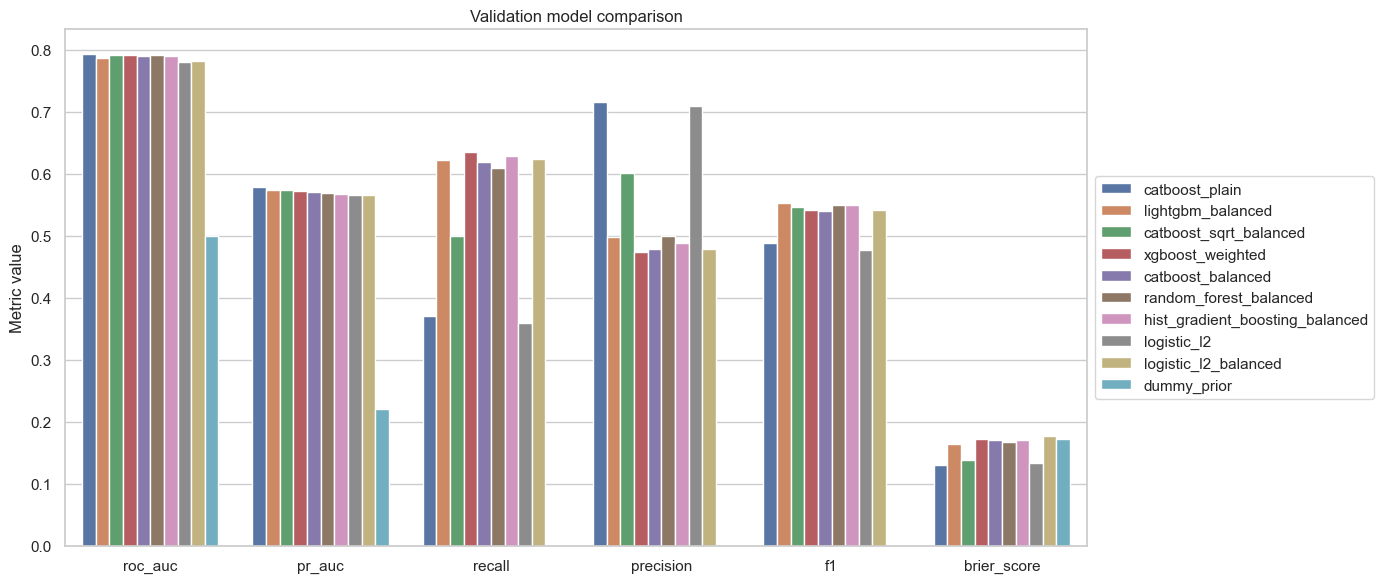

In [8]:
metric_columns = ["roc_auc", "pr_auc", "recall", "precision", "f1", "brier_score"]
plot_metrics = validation_metrics.melt(
    id_vars=["model", "family"],
    value_vars=metric_columns,
    var_name="metric",
    value_name="value",
)

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=plot_metrics, x="metric", y="value", hue="model", ax=ax)
ax.set_title("Validation model comparison")
ax.set_xlabel("")
ax.set_ylabel("Metric value")
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

C:\Users\chris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\chris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


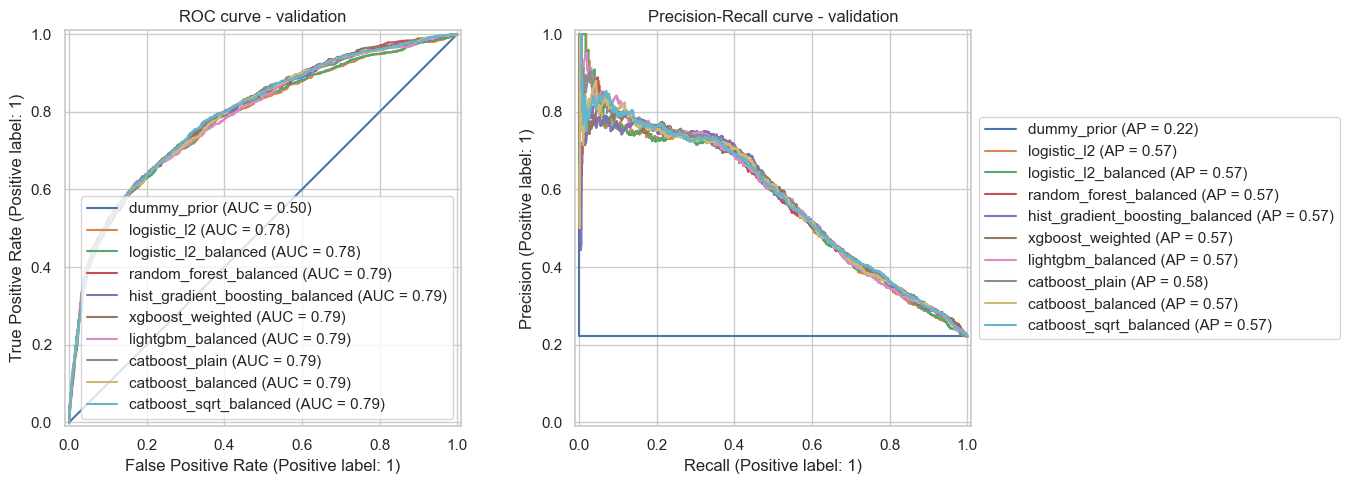

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for model_name, model in fitted_models.items():
    RocCurveDisplay.from_estimator(model, X_valid, y_valid, name=model_name, ax=axes[0])
    PrecisionRecallDisplay.from_estimator(model, X_valid, y_valid, name=model_name, ax=axes[1])
axes[0].set_title("ROC curve - validation")
axes[1].set_title("Precision-Recall curve - validation")
axes[1].legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

## 6. Model and Threshold Selection

The model is selected on validation PR-AUC. The classification threshold is selected on validation F1 instead of assuming that `0.50` is always the right cutoff.

In [10]:
best_model_name = validation_metrics.iloc[0]["model"]
best_validation_model = fitted_models[best_model_name]
valid_scores = positive_class_scores(best_validation_model, X_valid)

threshold_table = build_threshold_table(y_valid, valid_scores)
best_threshold = choose_threshold_by_f1(threshold_table)

print(f"Best validation model: {best_model_name}")
print(f"Selected threshold by validation F1: {best_threshold:.3f}")

display(threshold_table.sort_values("f1", ascending=False).head(10))

Best validation model: catboost_plain
Selected threshold by validation F1: 0.300


,threshold,precision,recall,sensitivity,specificity,balanced_accuracy,f1,predicted_positive_rate,true_negative,false_positive,false_negative,true_positive
10,0.3000,0.5680,0.5497,0.5497,0.8813,0.7155,0.5587,0.2140,3089,416,448,547
8,0.2500,0.5221,0.5940,0.5940,0.8456,0.7198,0.5557,0.2516,2964,541,404,591
11,0.3250,0.5851,0.5286,0.5286,0.8936,0.7111,0.5554,0.1998,3132,373,469,526
9,0.2750,0.5433,0.5678,0.5678,0.8645,0.7162,0.5553,0.2311,3030,475,430,565
7,0.2250,0.4910,0.6291,0.6291,0.8148,0.7220,0.5515,0.2833,2856,649,369,626
13,0.3750,0.6364,0.4784,0.4784,0.9224,0.7004,0.5462,0.1662,3233,272,519,476
12,0.3500,0.5995,0.4995,0.4995,0.9053,0.7024,0.5450,0.1842,3173,332,498,497
6,0.2000,0.4513,0.6663,0.6663,0.7700,0.7182,0.5381,0.3264,2699,806,332,663
14,0.4000,0.6559,0.4503,0.4503,0.9330,0.6916,0.5340,0.1518,3270,235,547,448
15,0.4250,0.6766,0.4332,0.4332,0.9412,0.6872,0.5282,0.1416,3299,206,564,431


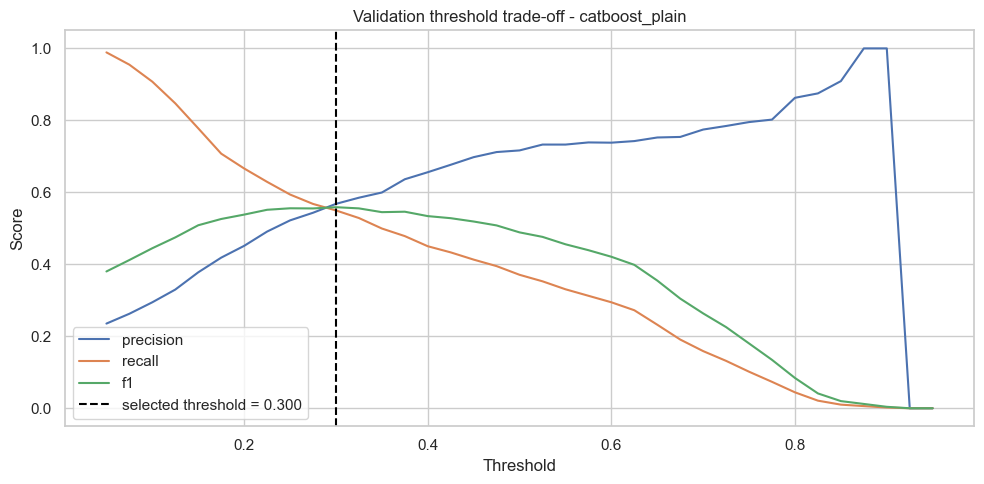

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.lineplot(data=threshold_table, x="threshold", y="precision", label="precision", ax=ax)
sns.lineplot(data=threshold_table, x="threshold", y="recall", label="recall", ax=ax)
sns.lineplot(data=threshold_table, x="threshold", y="f1", label="f1", ax=ax)
ax.axvline(best_threshold, color="black", linestyle="--", label=f"selected threshold = {best_threshold:.3f}")
ax.set_title(f"Validation threshold trade-off - {best_model_name}")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Final Test Evaluation

After selection, the chosen model is retrained on train plus validation and evaluated once on the test set.

In [12]:
X_final_train = pd.concat([X_train, X_valid], axis=0)
y_final_train = pd.concat([y_train, y_valid], axis=0)
final_pos_weight = positive_class_weight(y_final_train)
final_spec = next(spec for spec in candidate_specs(final_pos_weight) if spec["name"] == best_model_name)

start = time.perf_counter()
final_model = fit_candidate(final_spec, X_final_train, y_final_train)
final_fit_seconds = time.perf_counter() - start

test_scores = positive_class_scores(final_model, X_test)
test_metrics = pd.DataFrame(
    [
        {
            "model": best_model_name,
            "threshold": best_threshold,
            "fit_seconds_train_valid": final_fit_seconds,
            **binary_classification_metrics(y_test, test_scores, threshold=best_threshold),
        }
    ]
)

test_confusion = confusion_matrix_frame(y_test, test_scores, threshold=best_threshold)

display(test_metrics)
display(test_confusion)

,model,threshold,fit_seconds_train_valid,roc_auc,pr_auc,brier_score,accuracy,balanced_accuracy,precision,recall,f1
0,catboost_plain,0.3000,21.4119,0.7886,0.5726,0.1326,0.8027,0.7096,0.5550,0.5427,0.5488


,predicted_non_default,predicted_default
actual_non_default,3072,433
actual_default,455,540


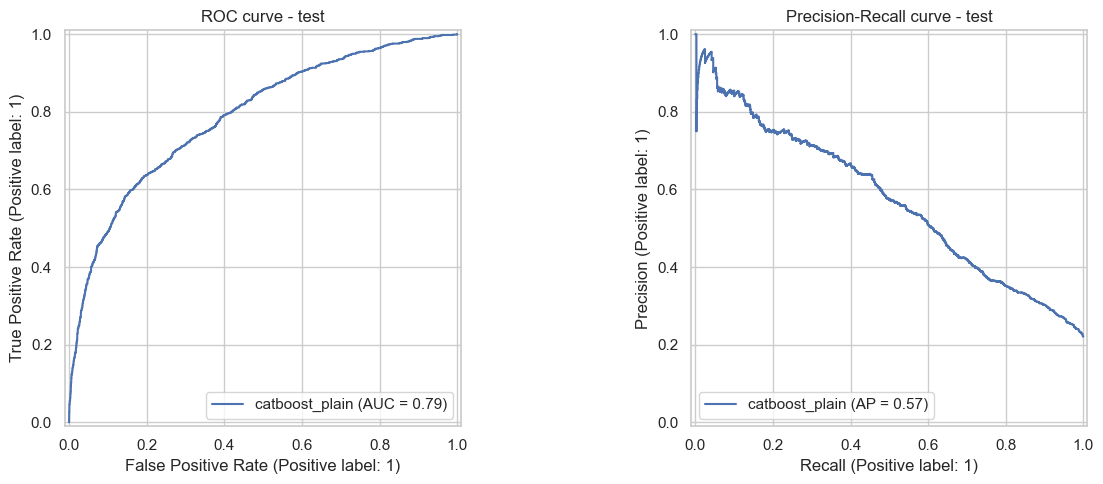

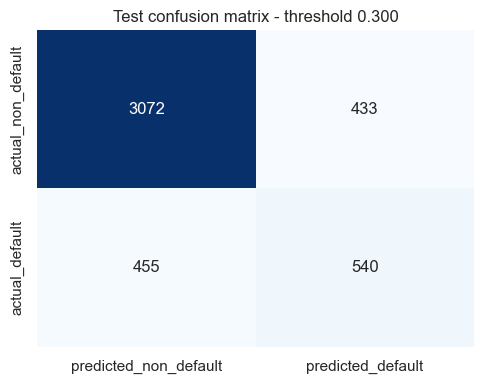

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
RocCurveDisplay.from_estimator(final_model, X_test, y_test, name=best_model_name, ax=axes[0])
PrecisionRecallDisplay.from_estimator(final_model, X_test, y_test, name=best_model_name, ax=axes[1])
axes[0].set_title("ROC curve - test")
axes[1].set_title("Precision-Recall curve - test")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(test_confusion, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title(f"Test confusion matrix - threshold {best_threshold:.3f}")
plt.tight_layout()
plt.show()

## 8. Feature Importance

Feature importance is used as a first model check. It helps verify that the selected model relies on plausible repayment and utilization signals.

In [14]:
def extract_feature_importance(estimator, feature_columns: pd.Index) -> pd.DataFrame:
    if hasattr(estimator, "named_steps"):
        feature_names = estimator.named_steps["preprocessor"].get_feature_names_out()
        model = estimator.named_steps["model"]
    else:
        feature_names = feature_columns.to_numpy()
        model = estimator

    if hasattr(model, "coef_"):
        signed_values = model.coef_.ravel()
        importance = abs(signed_values)
        return pd.DataFrame(
            {
                "feature": feature_names,
                "importance": importance,
                "signed_value": signed_values,
            }
        ).sort_values("importance", ascending=False)

    if hasattr(model, "feature_importances_"):
        return pd.DataFrame(
            {
                "feature": feature_names,
                "importance": model.feature_importances_,
                "signed_value": pd.NA,
            }
        ).sort_values("importance", ascending=False)

    return pd.DataFrame(columns=["feature", "importance", "signed_value"])


feature_importance = extract_feature_importance(final_model, X_final_train.columns)
display(feature_importance.head(30))

,feature,importance,signed_value
35,recent_delay_status,15.0117,<NA>
34,max_delay_status,4.9972,<NA>
36,mean_positive_delay,4.2230,<NA>
0,LIMIT_BAL,4.0239,<NA>
32,delinquency_months,3.6674,<NA>
2,BILL_AMT1,3.5691,<NA>
33,severe_delinquency_months,3.2411,<NA>
8,PAY_AMT1,3.0823,<NA>
55,PAY_0_category,2.7383,<NA>
48,total_payment_amount,2.3329,<NA>


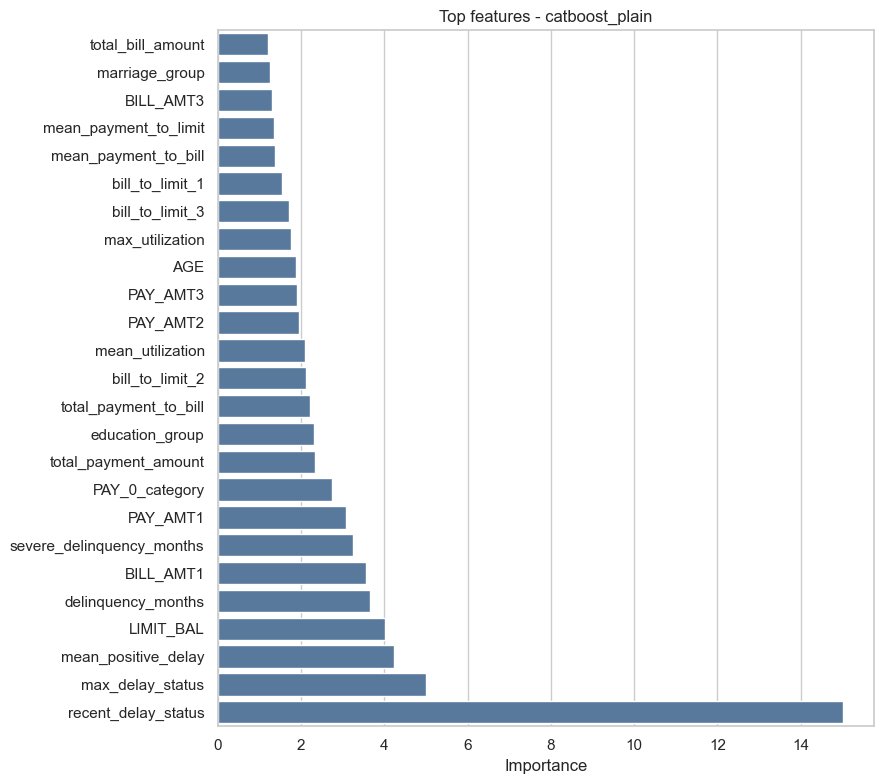

In [15]:
if not feature_importance.empty:
    top_importance = feature_importance.head(25).sort_values("importance", ascending=True)
    fig, ax = plt.subplots(figsize=(9, 8))
    sns.barplot(data=top_importance, x="importance", y="feature", color="#4C78A8", ax=ax)
    ax.set_title(f"Top features - {best_model_name}")
    ax.set_xlabel("Importance")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()
else:
    print("The selected model does not expose native feature importance.")

## 9. Save Artifacts

Metrics, threshold tables, feature importance, the confusion matrix, and the fitted pipeline are saved for reporting and downstream scoring.

In [16]:
validation_metrics_path = TABLES_DIR / "model_validation_metrics.csv"
threshold_table_path = TABLES_DIR / "model_best_threshold_validation.csv"
test_metrics_path = TABLES_DIR / "model_test_metrics.csv"
test_confusion_path = TABLES_DIR / "model_test_confusion_matrix.csv"
feature_importance_path = TABLES_DIR / "model_best_feature_importance.csv"
split_summary_path = TABLES_DIR / "model_split_summary.csv"
model_path = MODELS_DIR / "best_baseline_model.joblib"

validation_metrics.to_csv(validation_metrics_path, index=False)
threshold_table.to_csv(threshold_table_path, index=False)
test_metrics.to_csv(test_metrics_path, index=False)
test_confusion.to_csv(test_confusion_path, index_label="actual")
feature_importance.to_csv(feature_importance_path, index=False)
split_summary.to_csv(split_summary_path, index=False)
joblib.dump(
    {
        "model_name": best_model_name,
        "threshold": best_threshold,
        "pipeline": final_model,
        "numeric_columns": MODEL_NUMERIC_COLUMNS,
        "categorical_columns": MODEL_CATEGORICAL_COLUMNS,
    },
    model_path,
)

exports = pd.DataFrame(
    [
        {"artifact": "validation metrics", "path": validation_metrics_path.relative_to(PROJECT_ROOT)},
        {"artifact": "threshold table", "path": threshold_table_path.relative_to(PROJECT_ROOT)},
        {"artifact": "test metrics", "path": test_metrics_path.relative_to(PROJECT_ROOT)},
        {"artifact": "test confusion matrix", "path": test_confusion_path.relative_to(PROJECT_ROOT)},
        {"artifact": "feature importance", "path": feature_importance_path.relative_to(PROJECT_ROOT)},
        {"artifact": "split summary", "path": split_summary_path.relative_to(PROJECT_ROOT)},
        {"artifact": "final model", "path": model_path.relative_to(PROJECT_ROOT)},
    ]
)
display(exports)

,artifact,path
0,validation metrics,reports\tables\model_validation_metrics.csv
1,threshold table,reports\tables\model_best_threshold_validation...
2,test metrics,reports\tables\model_test_metrics.csv
3,test confusion matrix,reports\tables\model_test_confusion_matrix.csv
4,feature importance,reports\tables\model_best_feature_importance.csv
5,split summary,reports\tables\model_split_summary.csv
6,final model,models\best_baseline_model.joblib


## 10. Summary

The baseline workflow keeps preprocessing inside pipelines, selects the model without using test data, and produces a reproducible model artifact.